In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms
import torch.nn.functional as F
from sklearn.model_selection import train_test_split




import os
os.environ['CUDA_LAUNCH_BLOCKING'] = "1"
import torch
# Rest of your script


# Preliminary Setup

In [3]:

# Set the device to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Data loading and preprocessing

In [4]:
xdata = []

# Assuming the Excel file is in the same directory as the script
file_name = "AllRamanData.xlsx"

# Read the Excel file
df = pd.read_excel(file_name, header=None)

# Extract wavenumbers which we assume to be in the first column
wavenumbers = df.iloc[4:233, 0].to_list()

# We'll identify each patient by the unique identifier in the first row
# and group columns by patient
patient_ids = df.iloc[0, 1:].unique()
print(f"patientid: {patient_ids.shape}")
# Initialize a list to hold the column indices or names where 'Upper' is found
columns_with_upper = []

# Loop through all columns in the DataFrame
for col in df.columns:
    # Check if 'Upper' is in the current column
    if 'Upper' in df[col].values:
        # If 'Upper' is found, add the column index or name to our list
        columns_with_upper.append(col)

# Output the columns that contain 'Upper'
print("Columns with 'Upper':", columns_with_upper)

# Initialize a list to hold the column indices or names where 'Upper' is found
columns_with_lower = []

# Loop through all columns in the DataFrame
for col in df.columns:
    # Check if 'lower' is in the current column
    if 'Lower' in df[col].values:
        # If 'lower' is found, add the column index or name to our list
        columns_with_lower.append(col)

# Output the columns that contain 'lower'
print("Columns with 'lower':", columns_with_lower)


for id in patient_ids:
    # Initialize a list to hold the column indices or names where 'id' is found
    columns_with_id = []

    # Loop through all columns in the DataFrame
    for col in df.columns:
        # Check if 'id' is in the current column
        if id == df.at[0, col]:
            # If 'id' is found, add the column index or name to our list
            columns_with_id.append(col)


    upper_data = []
    lower_data = []

    cont = False

    upperC = 0
    lowerC = 0

    for col_index in columns_with_id:
        if(col_index in columns_with_upper):
            upper_data.append(df.iloc[4:233, col_index].to_list())
            upperC +=1
        elif(col_index in columns_with_lower):
            lower_data.append(df.iloc[4:233, col_index].to_list())
            lowerC += 1

    if(upperC == 0 or lowerC == 0):
        continue

    upper_data = np.array(upper_data)
    lower_data = np.array(lower_data)

    avg_upper_data = np.mean(upper_data, axis= 0)
    avg_lower_data = np.mean(lower_data, axis= 0)

    avg_upper_data = avg_upper_data.tolist()
    avg_lower_data = avg_lower_data.tolist()


    sample = np.vstack((wavenumbers, avg_upper_data, avg_lower_data)).tolist()
    xdata.append(sample)



xdata = torch.tensor(xdata, dtype=torch.float32)

print(xdata[0].shape)
print(len(xdata))

patientid: (59,)
Columns with 'Upper': [1, 2, 5, 6, 10, 11, 12, 15, 16, 19, 23, 27, 28, 29, 33, 34, 35, 39, 40, 45, 46, 47, 48, 53, 54, 59, 60, 61, 65, 66, 67, 70, 71, 72, 77, 78, 79, 80, 85, 89, 90, 94, 95, 98, 99, 100, 105, 106, 107, 111, 112, 113, 117, 118, 119, 123, 124, 125, 129, 130, 131, 133, 134, 135, 140, 141, 142, 146, 147, 151, 152, 153, 155, 156, 157, 161, 162, 163, 167, 168, 169, 174, 175, 176, 180, 181, 182, 186, 187, 188, 192, 193, 194, 198, 199, 200, 201, 205, 206, 207, 210, 211, 212, 216, 217, 222, 223, 224, 228, 229, 230, 234, 235, 240, 241, 242, 246, 250, 251, 252, 255, 256, 257, 258, 259, 260, 264, 265, 266, 270, 271, 272, 279, 280, 281, 285, 286, 287, 291, 292, 293, 297, 298, 299, 303, 304, 305, 309, 310, 311, 312, 316, 317, 318, 322, 323, 324, 328, 329, 330]
Columns with 'lower': [3, 4, 7, 8, 9, 13, 14, 17, 18, 20, 21, 22, 24, 25, 26, 30, 31, 32, 36, 37, 38, 41, 42, 43, 44, 49, 50, 51, 52, 55, 56, 57, 58, 62, 63, 64, 68, 69, 73, 74, 75, 76, 81, 82, 83, 84, 86, 87,

In [5]:
# Custom dataset class
class MatrixDataset(Dataset):
    def __init__(self, matrices):
        self.matrices = matrices
    
    def __len__(self):
        return len(self.matrices)
    
    def __getitem__(self, idx):
        matrix = self.matrices[idx]
        
        # Convert lists or tuples to numpy arrays with dtype float
        if isinstance(matrix, (list, tuple)):
            matrix = np.array(matrix, dtype=np.float32)
        
        # If the dtype of the matrix is 'object', attempt to convert it to 'float'
        if matrix.dtype == np.object_:
            matrix = matrix.astype(np.float32)
        
        # Convert the numpy array to a PyTorch tensor
        matrix_tensor = torch.tensor(matrix, dtype=torch.float)

        return matrix_tensor

    
    
# Convert list of matrices to dataset
# dataset = MatrixDataset(xdata)
dataset =  (xdata - xdata.mean()) / xdata.std()


# Split the dataset into training and validation sets (80-20 split here)
train_size = int(len(dataset) * 0.8)
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Print out the sizes to confirm
print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")


Training dataset size: 45
Validation dataset size: 12


# Architecture

In [6]:

class ConvVAE(nn.Module):
    def __init__(self, in_channels=3, latent_dim=3):
        super(ConvVAE, self).__init__()
        # Assuming in_channels is 3 as per the input data shape (3, 229)
        
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv1d(in_channels, 3, kernel_size=3, stride=3, padding=1),  # Output: (16, 229)
            nn.MaxPool1d(kernel_size=2, stride=1),
            # nn.BatchNorm1d(3),
            nn.ReLU(),
            nn.Conv1d(3, 3, kernel_size=3, stride=3, padding=1),  # Output: (3, 115)
            nn.MaxPool1d(kernel_size=2, stride=1),
            # nn.BatchNorm1d(3),
            nn.ReLU(),
            nn.Conv1d(3, 3, kernel_size=3, stride=3, padding=1),  # Output: (3, 58)
            nn.MaxPool1d(kernel_size=2, stride=1),
            # nn.BatchNorm1d(3),
            nn.ReLU(),
            nn.Conv1d(3, 3, kernel_size=3, stride=3, padding=0), # Output: (128, 29)
            nn.MaxPool1d(kernel_size=2, stride=1),
            # nn.BatchNorm1d(3),
            nn.ReLU(),
        )
        
        # Calculate the flattened feature size after all convolutions
        #              features x rows
        self.flattened_size = 3 * 1

        # Fully connected layers for learning the mean and log variance
        self.fc_mu = nn.Linear(self.flattened_size, latent_dim)
        self.fc_log_var = nn.Linear(self.flattened_size, latent_dim)
        
        # Decoder
        self.decoder_fc = nn.Linear(latent_dim, 3 * 58)  # Upscale to match the flattened size after encoder
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose1d(3, 3, kernel_size=3, stride=3, padding=0),
            nn.ReLU(),
            nn.ConvTranspose1d(3, 3, kernel_size=3, stride=3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(3, 3, kernel_size=3, stride=3, padding=1),
            nn.ReLU(),
            nn.ConvTranspose1d(3, 3, kernel_size=3, stride=3, padding=1),
            nn.ReLU(),
            nn.Upsample(size=229, mode='linear'),  # Upsample to original size
        )

        
    def reparameterize(self, mu, log_var):
        std = torch.exp(0.5 * log_var)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        # Encoder
        x = self.encoder(x)
        x = x.view(x.size(0), -1)
        mu = self.fc_mu(x)
        log_var = self.fc_log_var(x)
        
        # Reparameterization trick
        z = self.reparameterize(mu, log_var)
        
        # Decoder
        x = self.decoder_fc(z)
        x = x.view(x.size(0), 3, -1)  # Reshape to match the output shape for the conv layers
        x = self.decoder_conv(x)
        return x, mu, log_var




# Setup and Train

In [7]:
# Initialize the VAE model
model = ConvVAE().to(device)

# Create data loaders
batch_size = 1  # You can adjust the batch size as needed
num_epochs = 500 
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)



Epoch 1, Train Loss: 553.0438, Test Loss: 526.1107
Epoch 51, Train Loss: 325.7362, Test Loss: 312.3501
Epoch 101, Train Loss: 308.7516, Test Loss: 294.4714
Epoch 151, Train Loss: 305.2419, Test Loss: 290.8132
Epoch 201, Train Loss: 303.6600, Test Loss: 289.4240
Epoch 251, Train Loss: 302.8868, Test Loss: 289.3092
Epoch 301, Train Loss: 302.5902, Test Loss: 288.3024
Epoch 351, Train Loss: 301.2457, Test Loss: 287.3384
Epoch 401, Train Loss: 301.2442, Test Loss: 287.4355
Epoch 451, Train Loss: 300.9211, Test Loss: 286.6534


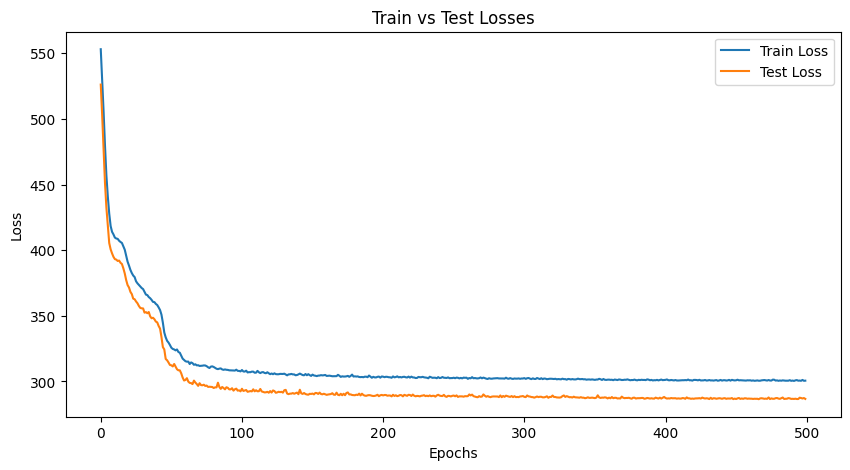

In [8]:

def train_epoch(model, train_loader, optimizer, device):
    model.train()
    total_loss = 0
    for x in train_loader:
        x = x.to(device)  # Send data to the correct device
        optimizer.zero_grad()
        reconstructed, mu, log_var = model(x)

        # Calculate loss
        recon_loss = F.mse_loss(reconstructed, x, reduction='sum')
        kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
        loss = recon_loss + kl_div

        # Backpropagation
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(train_loader.dataset)

def test_epoch(model, test_loader, device):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x in test_loader:
            x = x.to(device)  # Send data to the correct device
            reconstructed, mu, log_var = model(x)

            # Calculate loss
            recon_loss = F.mse_loss(reconstructed, x, reduction='sum')
            kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp())
            loss = recon_loss + kl_div
            total_loss += loss.item()
    return total_loss / len(test_loader.dataset)


# Initialize lists to keep track of losses
train_losses = []
test_losses = []

# Training loop
for epoch in range(num_epochs):
    train_loss = train_epoch(model, train_loader, optimizer, device)
    test_loss = test_epoch(model, test_loader, device)
    train_losses.append(train_loss)
    test_losses.append(test_loss)
    if(epoch % 50 == 0):
        print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

# Plotting the losses
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Train vs Test Losses')
plt.legend()
plt.show()


In [11]:
# data = torch.randn(10, 3, 229)  # Example data with shape (batch_size, channels, length)

# Initialize the VAE
# Make sure the in_channels and latent_dim parameters match your needs
vae = ConvVAE(in_channels=3, latent_dim=3)



# Forward pass through the encoder to get the compressed representation
vae.eval()  # Set the VAE to evaluation mode
with torch.no_grad():
    _, mu, _ = vae(dataset)
    compressed_data = mu.numpy()  # Convert to numpy array

# Save the compressed data to an Excel file
df = pd.DataFrame(compressed_data)
df.to_excel("compressed_data.xlsx", index=False)